# KNN Model with PCA

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Read dataset
df_new = pd.read_csv(r"E:\Project_Analysis\Nutri_Class_project\Data\cleaned_encoded_food_dataset.csv")

In [3]:
df_new

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,...,Is_Gluten_Free_label,Food_Name_label,Meal_Type_breakfast,Meal_Type_dinner,Meal_Type_lunch,Meal_Type_snack,Preparation_Method_baked,Preparation_Method_fried,Preparation_Method_grilled,Preparation_Method_raw
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,...,0,6,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,...,1,4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,...,0,2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,...,1,9,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,...,0,3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31320,103.937793,1.251053,0.452045,27.891970,14.836599,1.835365,2.326263,0.000000,53.690101,72.507408,...,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
31321,246.063812,10.269973,13.106895,36.416636,5.684908,1.571570,600.167326,20.839330,81.153823,41.760973,...,0,6,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
31322,299.997105,12.431992,11.512833,33.808189,5.737315,2.901049,586.095363,28.956145,75.144055,37.981317,...,0,6,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31323,352.146284,9.170255,8.340631,39.261887,1.731604,0.027763,20.681808,7.559997,73.299415,48.435802,...,0,5,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [4]:
df_pca = df_new.copy()
df_pca

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,...,Is_Gluten_Free_label,Food_Name_label,Meal_Type_breakfast,Meal_Type_dinner,Meal_Type_lunch,Meal_Type_snack,Preparation_Method_baked,Preparation_Method_fried,Preparation_Method_grilled,Preparation_Method_raw
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,...,0,6,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,...,1,4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,...,0,2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,...,1,9,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,...,0,3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31320,103.937793,1.251053,0.452045,27.891970,14.836599,1.835365,2.326263,0.000000,53.690101,72.507408,...,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
31321,246.063812,10.269973,13.106895,36.416636,5.684908,1.571570,600.167326,20.839330,81.153823,41.760973,...,0,6,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
31322,299.997105,12.431992,11.512833,33.808189,5.737315,2.901049,586.095363,28.956145,75.144055,37.981317,...,0,6,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31323,352.146284,9.170255,8.340631,39.261887,1.731604,0.027763,20.681808,7.559997,73.299415,48.435802,...,0,5,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [5]:
# Feature for PCA
X_pca = df_pca.drop(columns=['Food_Name_label'])
y = df_new['Food_Name_label']
X_pca.shape

(31325, 21)

In [6]:
np.unique(y)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [7]:
from sklearn.preprocessing import StandardScaler

#Standard scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)
X_scaled

array([[ 0.23626248,  0.82269474,  0.30938543, ...,  1.75737251,
        -0.57822267, -0.57851757],
       [-0.64765663, -0.82183419, -0.07839377, ..., -0.56903132,
        -0.57822267,  1.72855598],
       [ 0.69313562,  0.82055065,  1.16660883, ..., -0.56903132,
        -0.57822267,  1.72855598],
       ...,
       [ 0.3445245 ,  0.5168308 , -0.09505546, ..., -0.56903132,
         1.72943756, -0.57851757],
       [ 0.93673259, -0.0060202 , -0.58106992, ..., -0.56903132,
         1.72943756, -0.57851757],
       [-0.74615803, -0.62278491,  0.19704214, ..., -0.56903132,
         1.72943756, -0.57851757]], shape=(31325, 21))

In [8]:
from sklearn.decomposition import PCA

# PCA
pca = PCA(0.97)

X_PCA = pca.fit_transform(X_scaled)
X_PCA.shape

(31325, 14)

#### The application of PCA reduced the original 21-dimensional feature space to 14 principal components while retaining approximately 95% of the total variance. This dimensionality reduction helps remove redundancy and multicollinearity among input features.

In [9]:
pca.n_components_

np.int64(14)

In [10]:
X_PCA[0]

array([ 1.95030787,  0.5325502 ,  1.02195234, -0.10025152, -0.94546976,
        0.23707672, -0.14769446, -1.1972528 ,  2.38109889,  0.12987271,
        0.62675794,  0.3265968 , -0.54987844,  0.42547575])

Cumulative explained variance: 0.9762609307432177


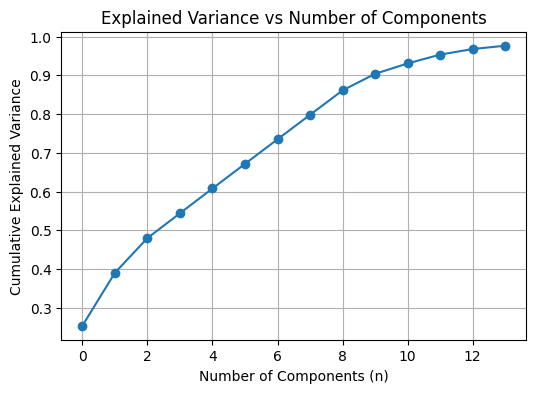

In [11]:
import numpy as np


print("Cumulative explained variance:",
      np.sum(pca.explained_variance_ratio_))

plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components (n)")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs Number of Components")
plt.grid()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

# 20% test, 60% train
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_PCA, y, test_size=0.2, random_state=30, stratify=y)

In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5,     # start with 5
    metric='euclidean' # default distance
)

knn.fit(X_train_pca, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [14]:
y_pred1 = knn.predict(X_train_pca)
y_pred1

array([0, 6, 8, ..., 2, 6, 6], shape=(25060,))

In [15]:
y_pred2 = knn.predict(X_test_pca)
y_pred2

array([2, 5, 6, ..., 6, 3, 3], shape=(6265,))

In [16]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


print("Train Accuracy", accuracy_score(y_train, y_pred1))
print("Test Accuracy:", accuracy_score(y_test, y_pred2))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred2))

Train Accuracy 0.9906624102154828
Test Accuracy: 0.9862729449321628

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       294
           1       0.97      0.98      0.98       237
           2       0.97      0.96      0.97       989
           3       1.00      1.00      1.00       893
           4       1.00      0.99      0.99       593
           5       0.99      1.00      0.99       792
           6       0.97      0.98      0.97      1183
           7       1.00      1.00      1.00       197
           8       0.99      0.99      0.99       397
           9       1.00      0.99      1.00       690

    accuracy                           0.99      6265
   macro avg       0.99      0.99      0.99      6265
weighted avg       0.99      0.99      0.99      6265



Text(95.72222222222221, 0.5, 'Actual')

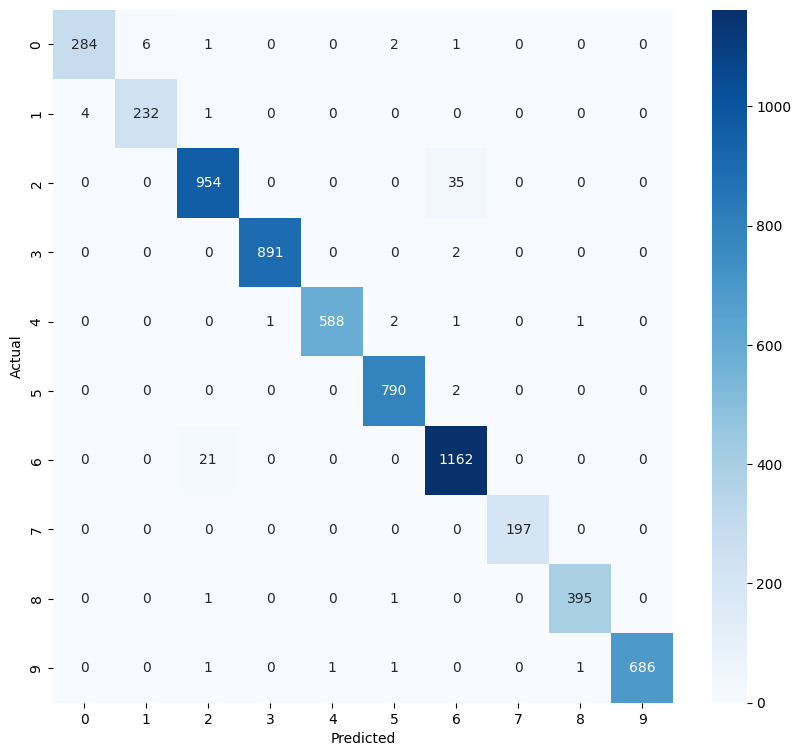

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred2)

plt.figure(figsize = (10, 9))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')